In [55]:
import sys, os, importlib.util
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c

from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math

HTML(""""
<style>
.output_png{
     display: table-cell;
     text-align: center;
     vertical-align: middle;
     }
</style>
""")

# Função para substituir importlib.load_source(nome, caminho)
def carregar_fonte(nome_modulo, caminho_arquivo):
    spec = importlib.util.spec_from_file_location(nome_modulo, caminho_arquivo)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[nome_modulo] = modulo
    spec.loader.exec_module(modulo)
    
    return modulo

#lumapiFile = "/opt/lumerical/v221/api/python/lumapi.py"
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"
lumapi = carregar_fonte("lumapi", lumapiFile)
emeApi = lumapi.MODE(hide = False)

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [56]:
import numpy as np

microns = 1e-6

nc = 1.5
nr = 3.5
lambda_0 = 1.550 *microns
k_0 = 2*np.pi/lambda_0
W_m = 7*microns

sigma = 0 # TE mode

We = W_m + (lambda_0/np.pi)*((nc/nr)**(2*sigma))*(nr**2-nc**2)**(-0.5)

neff = np.zeros(3)

for v in range(3):

    neff[v] = nr - ((v+1)**2 * np.pi * lambda_0)/(We**2 *4*nr*k_0)

Lpi = lambda_0 / (neff[0] - neff[2])

L = (3*Lpi)/2

print("Comprimento central = %.4f microns"  %(L*1e6))

Comprimento central = 173.4486 microns


GEOMETRIA DISPOSITIVO

In [57]:
# Variáveis auxiliares

largura_guia = 0.45 *microns
altura_guia = 0.22 *microns

largura_taper = 1.5*microns
comprimento_taper = 15 *microns

Wm = 7 *microns
L = 173.4 *microns

comprimento_porta = 4 *microns

In [58]:
def geometriaMMI():

    # Caixa central

    emeApi.addrect()
    emeApi.set("name", "Caixa central")
    emeApi.set("x span", L)
    emeApi.set("y span", Wm)
    emeApi.set("z span", altura_guia)
    emeApi.set("x", 0)
    emeApi.set("y", 0)
    emeApi.set("z", 0)
    emeApi.set("material", "Si (Silicon) - Palik")

    # Tapers

    emeApi.addobject("linear_taper")
    emeApi.set("name", "taper1")
    emeApi.set("thickness", altura_guia)
    emeApi.set("width_l", largura_guia)
    emeApi.set("width_r", largura_taper)
    emeApi.set("len", comprimento_taper)
    emeApi.set("x", -(L/2 + comprimento_taper/2))
    emeApi.set("y", We/6)
    emeApi.set("z", 0)
    emeApi.set("angle_side", 90)
    emeApi.set("material", "Si (Silicon) - Palik")

    emeApi.addobject("linear_taper")
    emeApi.set("name", "taper2")
    emeApi.set("thickness", altura_guia)
    emeApi.set("width_l", largura_guia)
    emeApi.set("width_r", largura_taper)
    emeApi.set("len", comprimento_taper)
    emeApi.set("x", -(L/2 + comprimento_taper/2))
    emeApi.set("y", -We/6)
    emeApi.set("z", 0)
    emeApi.set("angle_side", 90)
    emeApi.set("material", "Si (Silicon) - Palik")

    emeApi.addobject("linear_taper")
    emeApi.set("name", "taper3")
    emeApi.set("thickness", altura_guia)
    emeApi.set("width_l", largura_taper)
    emeApi.set("width_r", largura_guia)
    emeApi.set("len", comprimento_taper)
    emeApi.set("x", L/2 + comprimento_taper/2)
    emeApi.set("y", We/6)
    emeApi.set("z", 0)
    emeApi.set("angle_side", 90)
    emeApi.set("material", "Si (Silicon) - Palik")

    emeApi.addobject("linear_taper")
    emeApi.set("name", "taper4")
    emeApi.set("thickness", altura_guia)
    emeApi.set("width_l", largura_taper)
    emeApi.set("width_r", largura_guia)
    emeApi.set("len", comprimento_taper)
    emeApi.set("x", L/2 + comprimento_taper/2)
    emeApi.set("y", -We/6)
    emeApi.set("z", 0)
    emeApi.set("angle_side", 90)
    emeApi.set("material", "Si (Silicon) - Palik")

    # Guias Retos

    emeApi.addrect()
    emeApi.set("name", "porta1")
    emeApi.set("x span", comprimento_porta)
    emeApi.set("y span", largura_guia)
    emeApi.set("z span", altura_guia)
    emeApi.set("x", -(L/2 + comprimento_taper + comprimento_porta/2))
    emeApi.set("y", We/6)
    emeApi.set("z", 0)
    emeApi.set("material", "Si (Silicon) - Palik")

    emeApi.addrect()
    emeApi.set("name", "porta2")
    emeApi.set("x span", comprimento_porta)
    emeApi.set("y span", largura_guia)
    emeApi.set("z span", altura_guia)
    emeApi.set("x", -(L/2 + comprimento_taper + comprimento_porta/2))
    emeApi.set("y", -We/6)
    emeApi.set("z", 0)
    emeApi.set("material", "Si (Silicon) - Palik")

    emeApi.addrect()
    emeApi.set("name", "porta3")
    emeApi.set("x span", comprimento_porta)
    emeApi.set("y span", largura_guia)
    emeApi.set("z span", altura_guia)
    emeApi.set("x", L/2 + comprimento_taper + comprimento_porta/2)
    emeApi.set("y", We/6)
    emeApi.set("z", 0)
    emeApi.set("material", "Si (Silicon) - Palik")

    emeApi.addrect()
    emeApi.set("name", "porta4")
    emeApi.set("x span", comprimento_porta)
    emeApi.set("y span", largura_guia)
    emeApi.set("z span", altura_guia)
    emeApi.set("x", L/2 + comprimento_taper + comprimento_porta/2)
    emeApi.set("y", -We/6)
    emeApi.set("z", 0)
    emeApi.set("material", "Si (Silicon) - Palik")

REGIÃO DE SIMULAÇÃO

In [59]:
# Margem na região de simulação
x_offset = 0.5 *microns
y_offset = 2 *microns
z_offset = 0.5 *microns

# Span das portas
port_z_span = 2 *microns
port_y_span = 2 *microns


# Numero de celulas por regiao
cell_wgd = 1
cell_taper = 16
cell_box = 1

# Metodo: 0 = none, 1 = CVCS
method_wgd = 0
method_taper = 1
method_box = 0

# Numero de modos
modes_wgd = 4
modes_taper = 10
modes_box = 32 

nfreqpoints = 20

In [60]:
def regiaosimulacao():
    # Adiciona solver
    emeApi.addeme()
    emeApi.set("x", 0)
    emeApi.set("y", 0)
    emeApi.set("z", 0)
    emeApi.set("x min", -(L/2+comprimento_taper+comprimento_porta))
    emeApi.set("y span", Wm + 2*y_offset)
    emeApi.set("z span", altura_guia + 2*z_offset)
    emeApi.set("background material", "SiO2 (Glass) - Palik")

    # Propriedades das células
    emeApi.set("number of cell groups", 5)
    emeApi.set("group spans", np.block([[comprimento_porta], [comprimento_taper], [L], [comprimento_taper], [comprimento_porta]]))
    emeApi.set("cells", np.block([[cell_wgd], [cell_taper], [cell_box], [cell_taper], [cell_wgd]]))
    emeApi.set("subcell method", np.block([[method_wgd], [method_taper], [method_box], [method_taper], [method_wgd]]))
    emeApi.set("allow custom eigensolver settings", True)
    emeApi.set("modes", np.block([[modes_wgd], [modes_taper], [modes_box], [modes_taper], [modes_wgd]]))
    emeApi.set("display cells", 1)

    # Número de células mesh sem regiões sobrevarridas
    emeApi.set("mesh cells y", 200)
    emeApi.set("mesh cells z", 200)

    # Condições de fronteira
    emeApi.set("y min bc", "PML")
    emeApi.set("y max bc", "PML")
    emeApi.set("z min bc", "Symmetric")
    emeApi.set("z max bc", "PML")

    # Configura portas

    emeApi.select("EME::Ports::port_1")
    emeApi.set("use full simulation span", 0)
    emeApi.set("y", We/6)
    emeApi.set("y span", port_y_span)
    emeApi.set("z", 0)
    emeApi.set("z span", port_z_span)
    emeApi.set("mode selection", "fundamental TE mode")

    emeApi.select("EME::Ports::port_2")
    emeApi.set("use full simulation span", 0)
    emeApi.set("port location", "left")
    emeApi.set("y", -We/6)
    emeApi.set("y span", port_y_span)
    emeApi.set("z", 0)
    emeApi.set("z span", port_z_span)
    emeApi.set("mode selection", "fundamental TE mode")

    emeApi.addemeport()
    emeApi.set("use full simulation span", 0)
    emeApi.set("port location", "right")
    emeApi.set("y", We/6)
    emeApi.set("y span", port_y_span)
    emeApi.set("z", 0)
    emeApi.set("z span", port_z_span)
    emeApi.set("mode selection", "fundamental TE mode")

    emeApi.addemeport()
    emeApi.set("use full simulation span", 0)
    emeApi.set("port location", "right")
    emeApi.set("y", -We/6)
    emeApi.set("y span", port_y_span)
    emeApi.set("z", 0)
    emeApi.set("z span", port_z_span)
    emeApi.set("mode selection", "fundamental TE mode")

    # Adiciona monitor

    emeApi.addemeprofile()
    emeApi.set("name", "profile")
    emeApi.set("monitor type", 3)  # 2D Z-normal
    emeApi.set("x", 0)
    emeApi.set("x span", emeApi.getnamed("EME", "x span"))
    emeApi.set("y", 0)
    emeApi.set("y span", Wm + 2*y_offset)
    emeApi.set("z", 0)

ANALISE - PROPAGATION SWEEP

In [61]:
geometriaMMI()
regiaosimulacao()

emeApi.save("EME MMI")
emeApi.run()

10
[176.13789474]


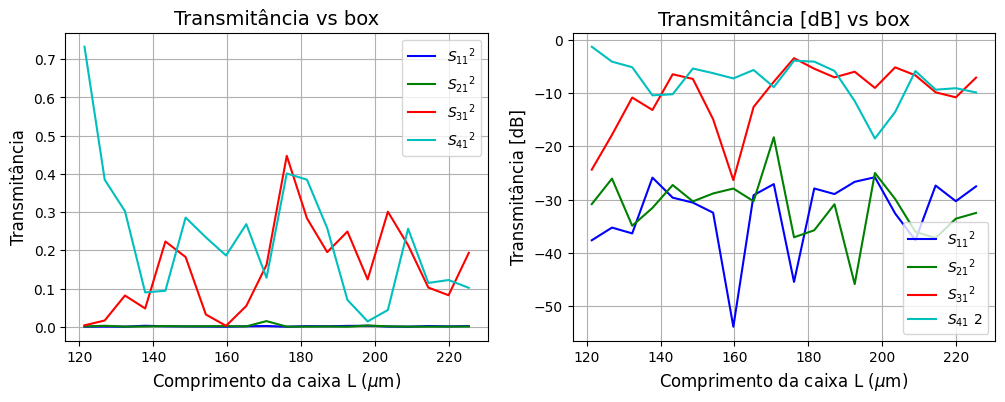

In [62]:
emeApi.setemeanalysis("propagation sweep", 1)
emeApi.setemeanalysis("parameter", "group span 3")
emeApi.setemeanalysis("start", 0.7 * L)
emeApi.setemeanalysis("stop", 1.3 * L)
emeApi.setemeanalysis("number of points", nfreqpoints)

emeApi.emesweep("propagation sweep")

S = emeApi.getemesweep('S')
group_span = S['group_span_3']

T1 = (np.abs(S['s11']))**2
T2 = (np.abs(S['s21']))**2
T3 = (np.abs(S['s31']))**2
T4 = (np.abs(S['s41']))**2

T1_dB = 10*np.log10(T1)
T2_dB = 10*np.log10(T2)
T3_dB = 10*np.log10(T3)
T4_dB = 10*np.log10(T4)

# Plotagem 

fig, axs = plt.subplots(1, 2, figsize = (12, 4))

axs[0].plot(group_span/microns, T1, 'b', lw = 1.5, label = '${S_{11}}^2$')
axs[0].plot(group_span/microns, T2, 'g', lw = 1.5, label = '${S_{21}}^2$')
axs[0].plot(group_span/microns, T3, 'r', lw = 1.5, label = '${S_{31}}^2$')
axs[0].plot(group_span/microns, T4, 'c', lw = 1.5, label = '${S_{41}}^2$')

axs[0].set_xlabel(r'Comprimento da caixa L ($\mu$m)', fontsize = 12)
axs[0].set_ylabel("Transmitância", fontsize = 12)
axs[0].set_title(r'Transmitância vs box', fontsize = 14)

axs[0].grid()
axs[0].legend()

axs[1].plot(group_span/microns, T1_dB, 'b', lw = 1.5, label = '${S_{11}}^2$')
axs[1].plot(group_span/microns, T2_dB, 'g', lw = 1.5, label = '${S_{21}}^2$')
axs[1].plot(group_span/microns, T3_dB, 'r', lw = 1.5, label = '${S_{31}}^2$')
axs[1].plot(group_span/microns, T4_dB, 'c', lw = 1.5, label = '${S_{41}}~2$')

axs[1].set_xlabel(r'Comprimento da caixa L ($\mu$m)', fontsize = 12)
axs[1].set_ylabel("Transmitância [dB]", fontsize = 12)
axs[1].set_title(r'Transmitância [dB] vs box', fontsize = 14)
axs[1].grid()
axs[1].legend()

i = np.argmax(T3)
print(i)
print(group_span[i]/microns)

In [63]:
emeApi.close()

ANALISE - WAVELENGTH SWEEP

In [64]:
import sys, os, importlib.util
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import lambda2nu, nu2lambda, c

from IPython.core.display import HTML
from IPython.core.pylabtools import figsize
from IPython.display import display, Math

HTML(""""
<style>
.output_png{
     display: table-cell;
     text-align: center;
     vertical-align: middle;
     }
</style>
""")

# Função para substituir importlib.load_source(nome, caminho)
def carregar_fonte(nome_modulo, caminho_arquivo):
    spec = importlib.util.spec_from_file_location(nome_modulo, caminho_arquivo)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[nome_modulo] = modulo
    spec.loader.exec_module(modulo)
    
    return modulo

#lumapiFile = "/opt/lumerical/v221/api/python/lumapi.py"
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"
lumapi = carregar_fonte("lumapi", lumapiFile)
emeApi = lumapi.MODE(hide = False)

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [65]:
L = 176 *microns

geometriaMMI()
regiaosimulacao()

emeApi.save("EME MMI")
emeApi.run()

0.45309529361419687
0.4053074162334655
[1.55263158e-06]


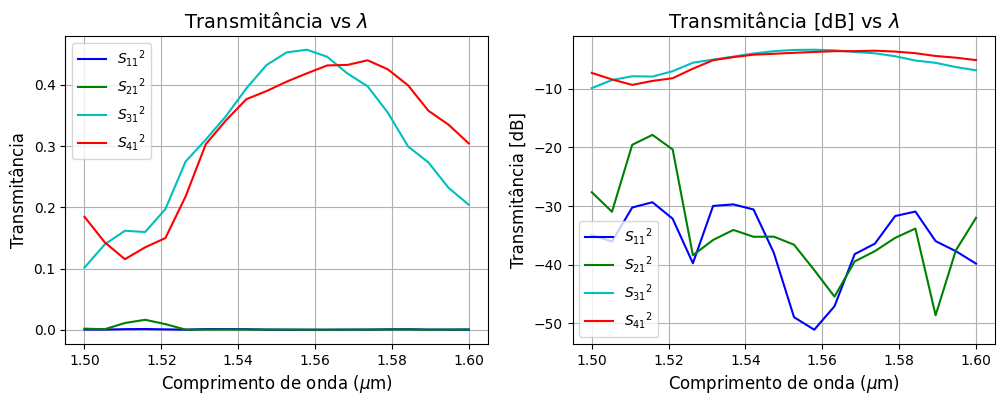

In [75]:
emeApi.setemeanalysis("wavelength sweep", 1)
emeApi.setemeanalysis("start wavelength", 1.5 *microns)
emeApi.setemeanalysis("stop wavelength", 1.6 *microns)
emeApi.setemeanalysis("number of wavelength points", nfreqpoints)
emeApi.setemeanalysis("calculate group delays", 1)

emeApi.emesweep("wavelength sweep")

S = emeApi.getemesweep('S_wavelength_sweep')
Lambda = S['wavelength']

T1 = np.abs(S['s11'])**2
T2 = np.abs(S['s21'])**2
T3 = np.abs(S['s31'])**2
T4 = np.abs(S['s41'])**2

T1_dB = 10*np.log10(T1)
T2_dB = 10*np.log10(T2)
T3_dB = 10*np.log10(T3)
T4_dB = 10*np.log10(T4)

fig, axs = plt.subplots(1, 2, figsize = (12, 4))

axs[0].plot(Lambda/microns, T1, 'b', lw = 1.5, label = '${S_{11}}^2$')
axs[0].plot(Lambda/microns, T2, 'g', lw = 1.5, label = '${S_{21}}^2$')
axs[0].plot(Lambda/microns, T3, 'c', lw = 1.5, label = '${S_{31}}^2$')
axs[0].plot(Lambda/microns, T4, 'r', lw = 1.5, label = '${S_{41}}^2$')

axs[0].set_xlabel(r'Comprimento de onda ($\mu$m)', fontsize = 12)
axs[0].set_ylabel("Transmitância", fontsize = 12)
axs[0].set_title(r'Transmitância vs $\lambda$', fontsize = 14)
axs[0].grid()
axs[0].legend()

axs[1].plot(Lambda/microns, T1_dB, 'b', lw = 1.5, label = '${S_{11}}^2$')
axs[1].plot(Lambda/microns, T2_dB, 'g', lw = 1.5, label = '${S_{21}}^2$')
axs[1].plot(Lambda/microns, T3_dB, 'c', lw = 1.5, label = '${S_{31}}^2$')
axs[1].plot(Lambda/microns, T4_dB, 'r', lw = 1.5, label = '${S_{41}}^2$')

axs[1].set_xlabel(r'Comprimento de onda ($\mu$m)', fontsize = 12)
axs[1].set_ylabel("Transmitância [dB]", fontsize = 12)
axs[1].set_title(r'Transmitância [dB] vs $\lambda$', fontsize = 14)
axs[1].grid()
axs[1].legend()

i = min(range(len(Lambda)), key=lambda i: abs(Lambda[i] - 1.55*microns))
print(T3[i+1])
print(T4[i+1])
print(Lambda[i+1])

C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_23800\33950776.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_23800\33950776.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()
C:\Users\mariana.lima\AppData\Local\Temp\ipykernel_23800\33950776.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend()


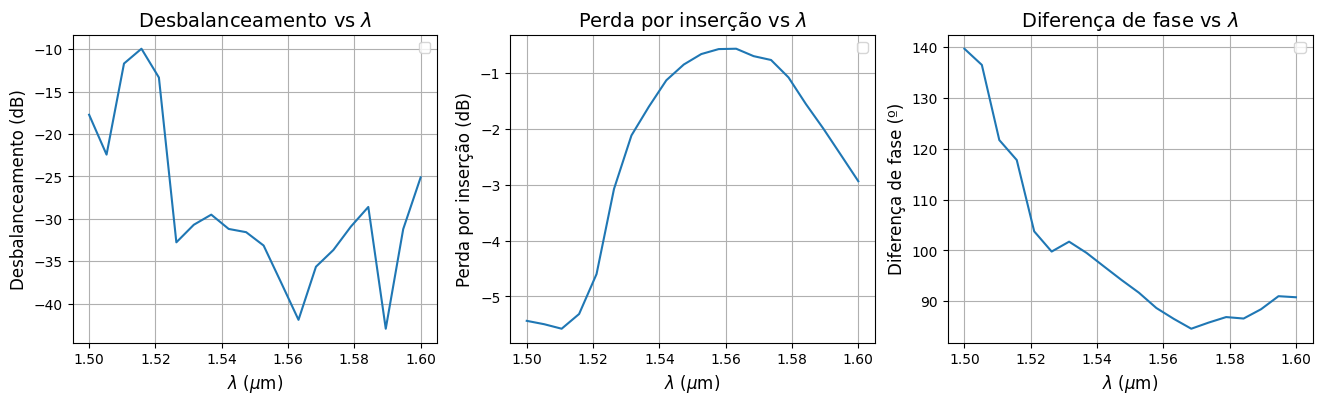

In [67]:
fig, axs = plt.subplots(1,3, figsize = (16,4))

# Imbalance

Ib = T2_dB - T3_dB

axs[0].plot(Lambda/microns, Ib, lw = 1.5)
axs[0].set_xlabel(r'$\lambda$ ($\mu$m)', fontsize = 12)
axs[0].set_ylabel("Desbalanceamento (dB)", fontsize = 12)
axs[0].set_title(r'Desbalanceamento vs $\lambda$', fontsize = 14)
axs[0].grid()
axs[0].legend()


# Insertion Loss

Il = 10*np.log10(T3 + T4)

axs[1].plot(Lambda/microns, Il, lw = 1.5)
axs[1].set_xlabel(r'$\lambda$ ($\mu$m)', fontsize = 12)
axs[1].set_ylabel("Perda por inserção (dB)", fontsize = 12)
axs[1].set_title(r'Perda por inserção vs $\lambda$', fontsize = 14)
axs[1].grid()
axs[1].legend()

# Phase shift

phi1 = np.angle(S['s31'])
phi2 = np.angle(S['s41'])

phase = (phi1 - phi2)*(180/np.pi)

for p in range(len(phase)):
    if (abs(phase[p]) > 180):
        phase[p] = phase[p] + 360

axs[2].plot(Lambda/microns, phase, lw = 1.5)
axs[2].set_xlabel(r'$\lambda$ ($\mu$m)', fontsize = 12)
axs[2].set_ylabel("Diferença de fase (º)", fontsize = 12)
axs[2].set_title(r'Diferença de fase vs $\lambda$', fontsize = 14)
axs[2].grid()
axs[2].legend()